In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pyccl as ccl
from scipy.interpolate            import InterpolatedUnivariateSpline as Spline
from scipy.optimize               import minimize_scalar
from velocileptors.LPT.cleft_fftw import CLEFT

In [3]:
cosmo = ccl.Cosmology(Omega_c=0.12/0.6736**2,Omega_b=0.02237/0.6736**2,
                      h=0.6736,n_s=0.9649,sigma8=0.80909,m_nu=[0,0,0.06],
                      transfer_function='boltzmann_camb',
                      matter_power_spectrum='halofit')
hub = cosmo["h"]
#
print("Omega_m =",cosmo["Omega_m"])
print("h       =",cosmo["h"])
print("mnu     =",cosmo["m_nu"])
print("omega_nu=",cosmo['Omega_nu_mass']*hub**2)
print("sigma8  =",cosmo.sigma8())

Omega_m = 0.31519186975361524
h       = 0.6736
mnu     = [0.06]
omega_nu= 0.000644200798721327
sigma8  = 0.80909


In [4]:
zz  = 3.0
chi = ccl.comoving_radial_distance(cosmo,1/(1+zz))*cosmo["h"]
print("Comoving distance to z={:.1f} is {:f}Mpc/h.".format(zz,chi))

Comoving distance to z=3.0 is 4383.429045Mpc/h.


In [5]:
bias = ccl.halos.hbias.sheth99.HaloBiasSheth99()
bias(cosmo,[1e11,1e12],1/(1+zz))

array([1.8657102 , 2.91849043])

In [6]:
kk    = np.geomspace(1e-3,30,500) # In h/Mpc.
pk_NL = ccl.nonlin_matter_power(cosmo,k=kk*hub,a=1/(1+zz))*hub**3
pk_lin= ccl.linear_matter_power(cosmo,k=kk*hub,a=1/(1+zz))*hub**3

In [7]:
# Define the halo model ingredients
mdef = ccl.halos.MassDef(200,'matter') # 200 times mean density
# Halo mass function
hmf = ccl.halos.MassFuncTinker08(mass_def=mdef)
# Halo bias function
hbf = ccl.halos.HaloBiasTinker10(mass_def=mdef)
# Halo density profile
c_m = ccl.halos.ConcentrationDuffy08(mass_def=mdef)
prof= ccl.halos.HaloProfileNFW(concentration=c_m,mass_def=mdef)
# Halo model calculator
hmc = ccl.halos.HMCalculator(mass_function=hmf,halo_bias=hbf,mass_def=mdef)

In [8]:
# Compute the total matter power spectrum (1-halo + 2-halo)
pk_HM = ccl.halos.halomod_power_spectrum(cosmo,hmc,k=kk*hub,a=1/(1+zz),prof=prof)*hub**3
pk_1h = ccl.halos.halomod_power_spectrum(cosmo,hmc,k=kk*hub,a=1/(1+zz),prof=prof,\
            get_1h=True,get_2h=False)*hub**3

In [9]:
# Load the Abacus N-body prediction.
# Files available at NERSC in
# /global/cfs/cdirs/desi/public/cosmosim/AbacusSummit/power/AbacusSummit_high_c000_ph100/
# Rebin to a log scale for plotting.
#
nbody = np.loadtxt("AbacusSummit_high_c000_ph100_z300_power.txt")
kn,pn = nbody[:,2],nbody[:,3]
Nmodes= nbody[:,-1]
# Rebin.
Nbins = 35
kvals = np.geomspace(7e-2,5.,Nbins+1)
kavg  = np.zeros(Nbins)
pavg  = np.zeros(Nbins)
for i in range(Nbins):
    ww      = np.nonzero( (kn>kvals[i])&(kn<kvals[i+1]) )[0]
    kavg[i] = np.sum(kn[ww]*Nmodes[ww])/np.sum(Nmodes[ww])
    pavg[i] = np.sum(pn[ww]*Nmodes[ww])/np.sum(Nmodes[ww])
kn,pn = kavg,pavg

In [10]:
# Compute the PT prediction.
cleft = CLEFT(kk,pk_lin)
# Compute the tables.
cleft.make_ptable(nk=200)
# find the best-fitting alpha:
def objective(alpha):
    kmin  = 0.20
    kmax  = 1.00
    ww    = np.nonzero( (kn>kmin)&(kn<kmax) )[0]
    kv    = cleft.pktable[:,0]
    pk_PT = cleft.pktable[:,1] + alpha*kv**2*cleft.pktable[:,13]
    pk_PT = Spline(kv,pk_PT)(kn[ww])
    chi2  = np.sum( (pk_PT-pn[ww])**2 )
    return(chi2)
#    
alpha = minimize_scalar(objective,bracket=(-1.,1.)).x
print("Best fitting alpha=",alpha)
ww    = np.nonzero(cleft.pktable[:,0]<1.00)[0]
kv    = cleft.pktable[ww,0]
pk_PT = cleft.pktable[ww,1] + alpha*kv**2*cleft.pktable[ww,13]
#

Best fitting alpha= 0.14603739157928525


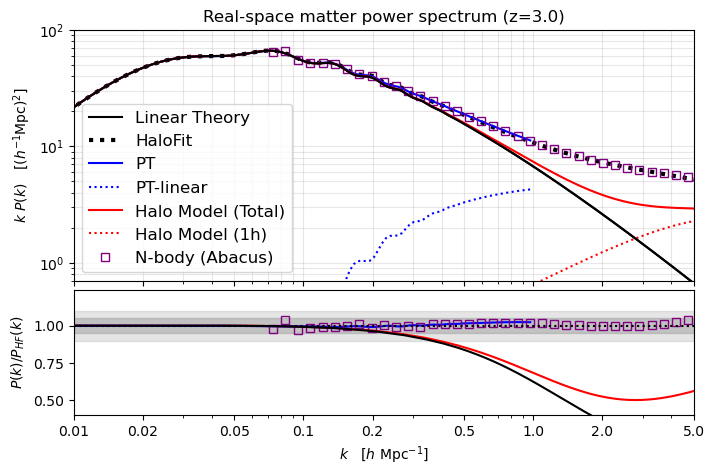

In [11]:
# Plot the results
fig,ax = plt.subplots(2,1,figsize=(8,5),sharex=True,
                      gridspec_kw={'height_ratios':[2,1],'hspace':0.05})
# Plot the full signal.
ax[0].loglog(kk,kk*pk_lin,'k-',label='Linear Theory')
ax[0].loglog(kk,kk*pk_NL, 'k:',label='HaloFit',lw=3)
ax[0].loglog(kv,kv*pk_PT, 'b-',label='PT')
ax[0].loglog(kv,kv*(pk_PT-Spline(kk,pk_lin)(kv)),'b:',label='PT-linear')
ax[0].loglog(kk,kk*pk_HM, 'r-',label='Halo Model (Total)')
ax[0].loglog(kk,kk*pk_1h, 'r:',label='Halo Model (1h)')
ax[0].loglog(kn,kn*pn,'s',mfc='None',color='purple',label='N-body (Abacus)')
ax[0].loglog(kk,kk*pk_lin,'k-')
# and the ratios to HaloFit.
ax[1].plot(kk,pk_HM /pk_NL,'r-')
ax[1].plot(kv,pk_PT /Spline(kk,pk_NL)(kv),'b-')
ax[1].plot(kn,pn    /Spline(kk,pk_NL)(kn),'s',mfc='None',color='purple')
ax[1].plot(kk,pk_lin/pk_NL,'k-')
# and tidy up.
ax[1].axhline(1.0,color='k',ls=':')
ax[1].axhspan(0.95,1.05,color='darkgrey',alpha=0.5)
ax[1].axhspan(0.9,1.1,color='grey',alpha=0.2)
for aa in ax:
    aa.set_xlim(1e-2,5.0)
ax[0].set_ylim(7e-1,1e2)
ax[1].set_ylim(0.4,1.24)
xticks = [0.01,0.02,0.05,0.1,0.2,0.5,1.0,2.,5.]
ax[1].set_xticks(xticks,[str(x) for x in xticks])
ax[1].set_xlabel(r'$k \quad [h\ \mathrm{Mpc}^{-1}]$')
ax[0].set_ylabel(r'$k\ P(k) \quad [(h^{-1}\mathrm{Mpc})^2]$')
ax[1].set_ylabel(r'$P(k)/P_{HF}(k)$')
ax[0].legend(fontsize=12)
ax[0].set_title('Real-space matter power spectrum (z={:.1f})'.format(zz))
ax[0].grid(True,which="both",alpha=0.3)
#
#fig.tight_layout()
plt.savefig('CCL_halomod.png',dpi=300)
plt.savefig('CCL_halomod.pdf')

# The End